<a href="https://colab.research.google.com/github/minhasaleem/tensorflow-ann-basics/blob/main/tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35 (140.00 B)

 Trainable params: 35 (140.00 B)

 Non-trainable params: 0 (0.00 B)

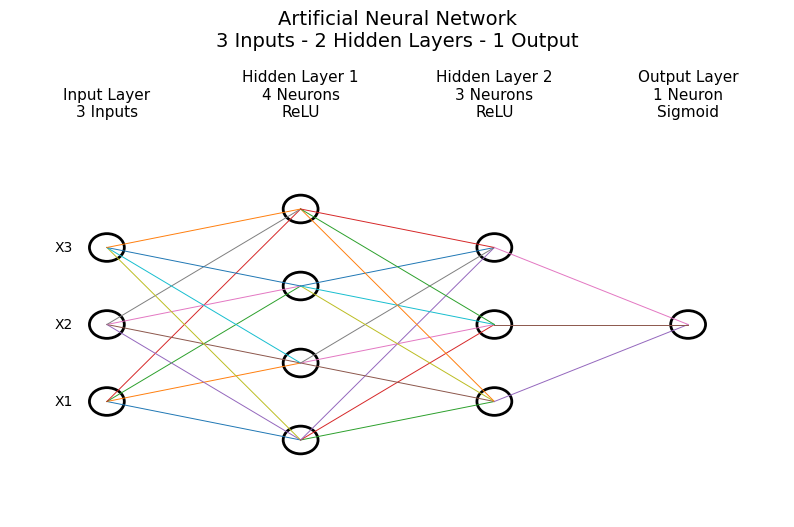

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
import matplotlib.pyplot as plt

# -----------------------------
# Create the ANN model
# -----------------------------

model = Sequential([
    Input(shape=(3,)),
    Dense(4, activation='relu', name='Hidden_Layer_1'),
    Dense(3, activation='relu', name='Hidden_Layer_2'),
    Dense(1, activation='sigmoid', name='Output_Layer')
])

# -----------------------------
# BOX/TABLE OUTPUT
# -----------------------------

model.summary()


# -----------------------------
# VISUAL NEURON DIAGRAM
# -----------------------------

layers = [3, 4, 3, 1]

layer_names = [
    'Input Layer\n3 Inputs',
    'Hidden Layer 1\n4 Neurons\nReLU',
    'Hidden Layer 2\n3 Neurons\nReLU',
    'Output Layer\n1 Neuron\nSigmoid'
]

fig, ax = plt.subplots(figsize=(10, 6))

positions = []

# Create neurons
for i, n_neurons in enumerate(layers):

    y_positions = [
        j - (n_neurons - 1) / 2
        for j in range(n_neurons)
    ]

    layer_positions = []

    for y in y_positions:
        x = i * 2

        circle = plt.Circle(
            (x, y),
            0.18,
            fill=False,
            linewidth=2
        )

        ax.add_patch(circle)
        layer_positions.append((x, y))

    positions.append(layer_positions)


# Draw connections between neurons
for i in range(len(positions) - 1):

    for x1, y1 in positions[i]:

        for x2, y2 in positions[i + 1]:

            ax.plot(
                [x1, x2],
                [y1, y2],
                linewidth=0.7
            )


# Add layer names
for i, name in enumerate(layer_names):

    ax.text(
        i * 2,
        2.7,
        name,
        ha='center',
        fontsize=11
    )


# Add input labels
for i, (x, y) in enumerate(positions[0]):

    ax.text(
        x - 0.35,
        y,
        f'X{i+1}',
        ha='right',
        va='center'
    )


ax.set_xlim(-1, 7)
ax.set_ylim(-2.5, 3.5)

ax.axis('off')

plt.title(
    'Artificial Neural Network\n3 Inputs - 2 Hidden Layers - 1 Output',
    fontsize=14
)

plt.show()